<a href="https://colab.research.google.com/github/kavitha-kaliyaperumal/Deep-Fake-Detection/blob/main/deepfake_brain_mri_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Deepfake Brain MRI Detection — Beginner Research Notebook

**Goal:** Learn to detect AI-generated (deepfake) brain MRI images using deep learning.

### 📋 What You Will Learn
1. Load and visualize brain MRI data
2. Understand what makes a deepfake MRI
3. Build a simple CNN classifier (Real vs Fake)
4. Use a pretrained model (Transfer Learning)
5. Evaluate your model with proper metrics
6. Visualize what the model 'looks at' (Grad-CAM)

> ⚠️ **Runtime:** Make sure you select `Runtime > Change runtime type > T4 GPU` for faster training.

## 📦 STEP 1 — Install & Import Libraries

In [1]:
# Install extra packages not in Colab by default
!pip install -q nibabel torchio grad-cam

import os, random, zipfile, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.utils import make_grid

from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Using device: {DEVICE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 96.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.1/202.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 14.5 MB/s eta 0:00:00
✅ Using device: cuda


## 🗂️ STEP 2 — Prepare Dataset

We'll use the **Brain Tumor MRI Dataset** from Kaggle as our 'real' images,
then synthetically generate fake samples using simple transformations (beginner-friendly approach).

**For real research**, you would use:
- [BraTS dataset](https://www.med.upenn.edu/cbica/brats/) — real clinical MRIs
- GAN-generated fakes (StyleGAN2, DCGAN, or a medical GAN)

Here we simulate this with a local synthetic approach so you can run it instantly.

In [2]:
# --- Create a synthetic MRI-like dataset for practice ---
# In real research: replace this with actual real/fake MRI folders

from pathlib import Path

DATA_DIR = Path('mri_dataset')
REAL_DIR = DATA_DIR / 'real'
FAKE_DIR = DATA_DIR / 'fake'
REAL_DIR.mkdir(parents=True, exist_ok=True)
FAKE_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
N_SAMPLES = 300  # per class (increase for better training)

def make_synthetic_mri(seed, is_fake=False):
    """Generate a grayscale synthetic MRI-like image."""
    rng = np.random.RandomState(seed)
    base = rng.randn(IMG_SIZE, IMG_SIZE)

    # Smooth to look like MRI texture
    from scipy.ndimage import gaussian_filter
    img = gaussian_filter(base, sigma=8)

    # Add circular 'brain' mask
    Y, X = np.ogrid[:IMG_SIZE, :IMG_SIZE]
    cx, cy, r = IMG_SIZE//2, IMG_SIZE//2, 90
    mask = (X - cx)**2 + (Y - cy)**2 <= r**2
    img = img * mask

    if is_fake:
        # Simulate GAN artifacts: extra noise + checkerboard
        noise = rng.randn(IMG_SIZE, IMG_SIZE) * 0.3
        checker = np.indices((IMG_SIZE, IMG_SIZE)).sum(axis=0) % 2 * 0.05
        img = img + noise * mask + checker * mask

    # Normalize to [0, 255]
    img = (img - img.min()) / (img.max() - img.min() + 1e-8) * 255
    return Image.fromarray(img.astype(np.uint8)).convert('RGB')

print('Generating synthetic dataset...')
for i in range(N_SAMPLES):
    make_synthetic_mri(i, is_fake=False).save(REAL_DIR / f'real_{i:04d}.png')
    make_synthetic_mri(i + 10000, is_fake=True).save(FAKE_DIR / f'fake_{i:04d}.png')

print(f'✅ Created {N_SAMPLES} real + {N_SAMPLES} fake MRI images')

Generating synthetic dataset...
✅ Created 300 real + 300 fake MRI images


## 👁️ STEP 3 — Visualize the Data

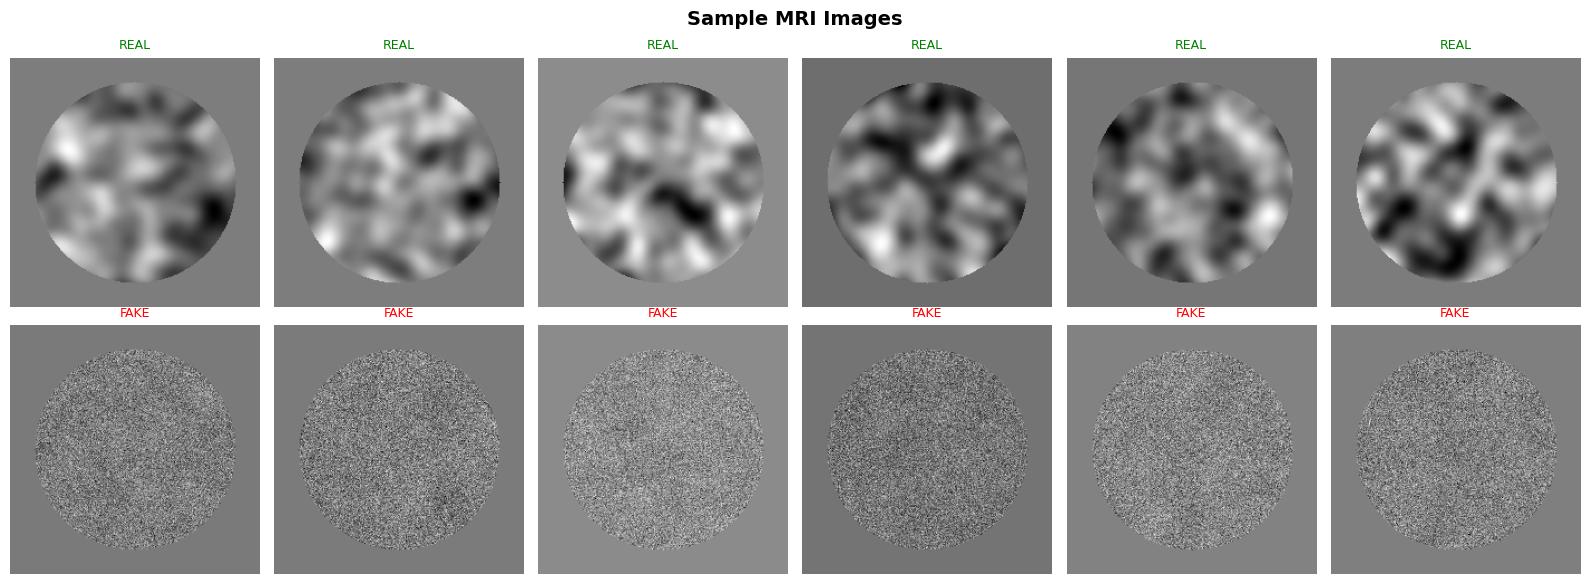

🔍 Notice: Fake images have subtle noise patterns — the model learns to detect these.


In [3]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('Sample MRI Images', fontsize=14, fontweight='bold')

real_imgs = sorted(REAL_DIR.glob('*.png'))[:6]
fake_imgs = sorted(FAKE_DIR.glob('*.png'))[:6]

for i, (r, f) in enumerate(zip(real_imgs, fake_imgs)):
    axes[0, i].imshow(Image.open(r), cmap='gray')
    axes[0, i].set_title('REAL', color='green', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(Image.open(f), cmap='gray')
    axes[1, i].set_title('FAKE', color='red', fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()
print('🔍 Notice: Fake images have subtle noise patterns — the model learns to detect these.')

## 🔧 STEP 4 — Build the PyTorch Dataset & DataLoaders

In [4]:
class MRIDataset(Dataset):
    """Custom Dataset: loads real=0, fake=1 images."""

    def __init__(self, real_dir, fake_dir, transform=None):
        self.transform = transform
        self.samples = []

        for p in sorted(Path(real_dir).glob('*.png')):
            self.samples.append((str(p), 0))  # label 0 = real
        for p in sorted(Path(fake_dir).glob('*.png')):
            self.samples.append((str(p), 1))  # label 1 = fake

        random.shuffle(self.samples)
        print(f'📊 Dataset: {len(self.samples)} images ({sum(l==0 for _,l in self.samples)} real, {sum(l==1 for _,l in self.samples)} fake)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Data augmentation for training; only normalize for validation
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

full_ds = MRIDataset(REAL_DIR, FAKE_DIR, transform=train_tf)

# 70/15/15 split
n = len(full_ds)
n_train = int(0.7 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val
train_ds, val_ds, test_ds = random_split(full_ds, [n_train, n_val, n_test])

# Apply val transform to val/test splits
val_ds.dataset.transform  = val_tf
test_ds.dataset.transform = val_tf

BATCH = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2)

print(f'\n✅ Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

📊 Dataset: 600 images (300 real, 300 fake)

✅ Train: 420 | Val: 90 | Test: 90


## 🏗️ STEP 5 — Model A: Simple Custom CNN (from scratch)

In [5]:
class SimpleCNN(nn.Module):
    """A lightweight CNN for binary (real/fake) classification."""

    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(4)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = SimpleCNN().to(DEVICE)

total_params = sum(p.numel() for p in cnn_model.parameters())
print(f'✅ SimpleCNN — Total parameters: {total_params:,}')
print(cnn_model)

✅ SimpleCNN — Total parameters: 2,488,066
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0

## 🚀 STEP 6 — Training Loop

In [6]:
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0

    for epoch in range(epochs):
        # --- Training phase ---
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()
            t_correct += (out.argmax(1) == labels).sum().item()
            t_total += labels.size(0)

        # --- Validation phase ---
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                v_loss += criterion(out, labels).item()
                v_correct += (out.argmax(1) == labels).sum().item()
                v_total += labels.size(0)

        train_acc = t_correct / t_total
        val_acc   = v_correct / v_total
        history['train_loss'].append(t_loss / len(train_loader))
        history['val_loss'].append(v_loss / len(val_loader))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')

        print(f'Epoch [{epoch+1:2d}/{epochs}] | '
              f'Train Loss: {history["train_loss"][-1]:.4f} Acc: {train_acc:.3f} | '
              f'Val Loss: {history["val_loss"][-1]:.4f} Acc: {val_acc:.3f} '
              f'{'⭐ BEST' if val_acc == best_val_acc else ''}')

    print(f'\n✅ Training complete! Best Val Accuracy: {best_val_acc:.4f}')
    return history

print('🏋️ Training SimpleCNN...')
history = train_model(cnn_model, train_loader, val_loader, epochs=15)

🏋️ Training SimpleCNN...
Epoch [ 1/15] | Train Loss: 0.0722 Acc: 0.967 | Val Loss: 7.5954 Acc: 0.467 ⭐ BEST
Epoch [ 2/15] | Train Loss: 0.0095 Acc: 0.995 | Val Loss: 5.0455 Acc: 0.467 ⭐ BEST
Epoch [ 3/15] | Train Loss: 0.0005 Acc: 1.000 | Val Loss: 0.0012 Acc: 1.000 ⭐ BEST
Epoch [ 4/15] | Train Loss: 0.0000 Acc: 1.000 | Val Loss: 0.0000 Acc: 1.000 ⭐ BEST
Epoch [ 5/15] | Train Loss: 0.0000 Acc: 1.000 | Val Loss: 0.0000 Acc: 1.000 ⭐ BEST
Epoch [ 6/15] | Train Loss: 0.0000 Acc: 1.000 | Val Loss: 0.0000 Acc: 1.000 ⭐ BEST
Epoch [ 7/15] | Train Loss: 0.0000 Acc: 1.000 | Val Loss: 0.0000 Acc: 1.000 ⭐ BEST
Epoch [ 8/15] | Train Loss: 0.0000 Acc: 1.000 | Val Loss: 0.0000 Acc: 1.000 ⭐ BEST
Epoch [ 9/15] | Train Loss: 0.0000 Acc: 1.000 | Val Loss: 0.0000 Acc: 1.000 ⭐ BEST
Epoch [10/15] | Train Loss: 0.0000 Acc: 1.000 | Val Loss: 0.0000 Acc: 1.000 ⭐ BEST
Epoch [11/15] | Train Loss: 0.0000 Acc: 1.000 | Val Loss: 0.0000 Acc: 1.000 ⭐ BEST
Epoch [12/15] | Train Loss: 0.0000 Acc: 1.000 | Val Loss: 0.00

## 📈 STEP 7 — Plot Training Curves

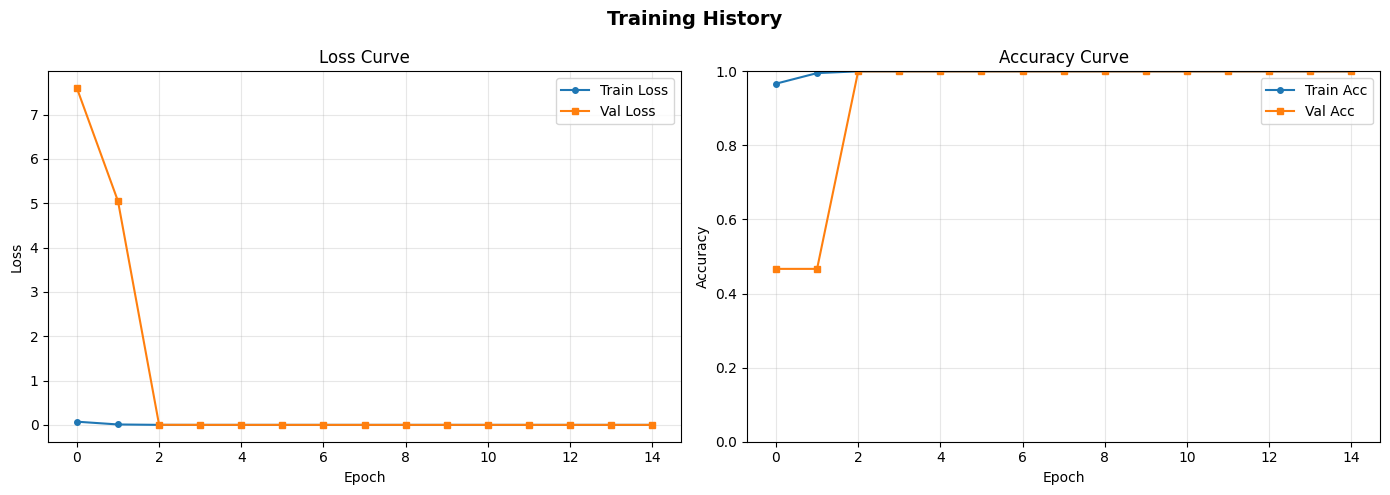

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

axes[0].plot(history['train_loss'], label='Train Loss', marker='o', markersize=4)
axes[0].plot(history['val_loss'],   label='Val Loss',   marker='s', markersize=4)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', marker='o', markersize=4)
axes[1].plot(history['val_acc'],   label='Val Acc',   marker='s', markersize=4)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curve'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 🔬 STEP 8 — Evaluate on Test Set

📊 Classification Report:
              precision    recall  f1-score   support

        Real       0.97      1.00      0.99        36
        Fake       1.00      0.98      0.99        54

    accuracy                           0.99        90
   macro avg       0.99      0.99      0.99        90
weighted avg       0.99      0.99      0.99        90

🎯 AUC-ROC Score: 1.0000


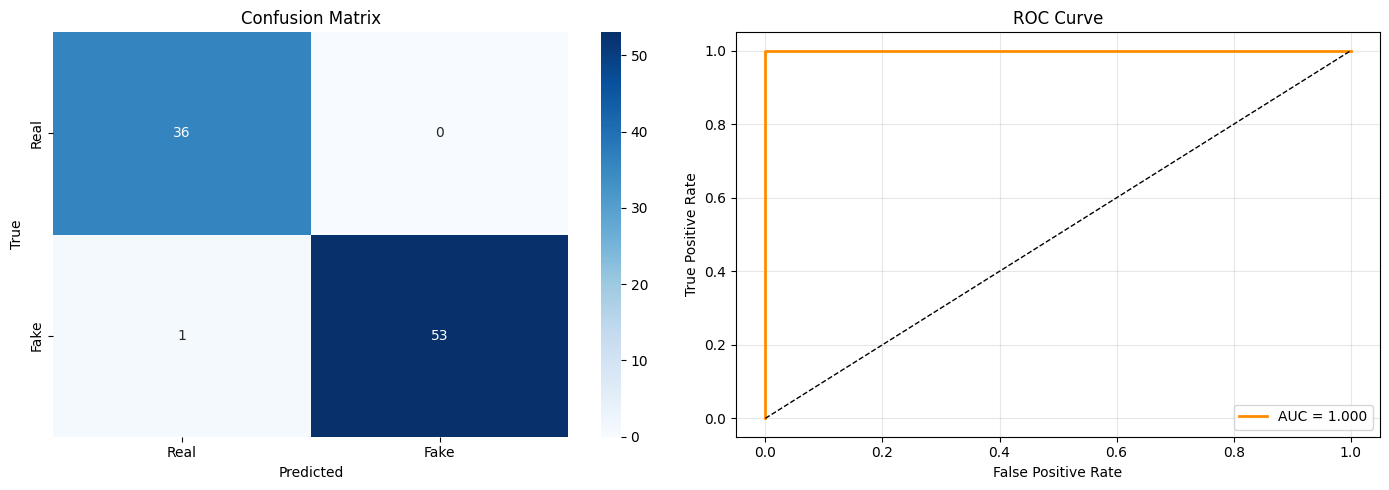

In [8]:
def evaluate(model, loader, model_path='best_model.pth'):
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            out  = model(imgs)
            probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    print('📊 Classification Report:')
    print(classification_report(all_labels, all_preds, target_names=['Real', 'Fake']))

    auc = roc_auc_score(all_labels, all_probs)
    print(f'🎯 AUC-ROC Score: {auc:.4f}')

    # Confusion Matrix
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    axes[0].set_title('Confusion Matrix'); axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='darkorange', lw=2)
    axes[1].plot([0,1],[0,1],'k--', lw=1)
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Curve'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return all_preds, all_labels, all_probs

preds, labels, probs = evaluate(cnn_model, test_loader)

## 🤖 STEP 9 — Model B: Transfer Learning with EfficientNet

Transfer learning uses a model **pre-trained on millions of images** (ImageNet) and fine-tunes it for your task. This is the standard approach in medical imaging research.

In [9]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def build_efficientnet():
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

    # Freeze backbone (optional — speeds up training)
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace final classifier for 2-class output
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, 2)
    )
    return model.to(DEVICE)

eff_model = build_efficientnet()
trainable = sum(p.numel() for p in eff_model.parameters() if p.requires_grad)
print(f'✅ EfficientNet-B0 loaded | Trainable params: {trainable:,}')
print('🏋️ Training EfficientNet (fine-tuning head only)...')
eff_history = train_model(eff_model, train_loader, val_loader, epochs=10, lr=1e-3)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 62.0MB/s]


✅ EfficientNet-B0 loaded | Trainable params: 2,562
🏋️ Training EfficientNet (fine-tuning head only)...
Epoch [ 1/10] | Train Loss: 0.4575 Acc: 0.840 | Val Loss: 0.2748 Acc: 1.000 ⭐ BEST
Epoch [ 2/10] | Train Loss: 0.1097 Acc: 0.998 | Val Loss: 0.1502 Acc: 1.000 ⭐ BEST
Epoch [ 3/10] | Train Loss: 0.0532 Acc: 0.995 | Val Loss: 0.0839 Acc: 1.000 ⭐ BEST
Epoch [ 4/10] | Train Loss: 0.0365 Acc: 0.998 | Val Loss: 0.0444 Acc: 1.000 ⭐ BEST
Epoch [ 5/10] | Train Loss: 0.0323 Acc: 1.000 | Val Loss: 0.0308 Acc: 1.000 ⭐ BEST
Epoch [ 6/10] | Train Loss: 0.0282 Acc: 1.000 | Val Loss: 0.0107 Acc: 1.000 ⭐ BEST
Epoch [ 7/10] | Train Loss: 0.0264 Acc: 1.000 | Val Loss: 0.0069 Acc: 1.000 ⭐ BEST
Epoch [ 8/10] | Train Loss: 0.0458 Acc: 0.995 | Val Loss: 0.0079 Acc: 1.000 ⭐ BEST
Epoch [ 9/10] | Train Loss: 0.0281 Acc: 1.000 | Val Loss: 0.0069 Acc: 1.000 ⭐ BEST
Epoch [10/10] | Train Loss: 0.0299 Acc: 1.000 | Val Loss: 0.0067 Acc: 1.000 ⭐ BEST

✅ Training complete! Best Val Accuracy: 1.0000


## 🔍 STEP 10 — Grad-CAM: Visualize What the Model Sees

**Grad-CAM** creates a heatmap showing which regions of the MRI influenced the model's decision. Critical for medical AI interpretability.

In [12]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# Load best weights
cnn_model.load_state_dict(torch.load('best_model.pth', map_location=DEVICE))
cnn_model.eval()

# Target last conv layer
target_layer = [cnn_model.features[-1]]
cam = GradCAM(model=cnn_model, target_layers=target_layer)

# Grab a few test images
imgs_batch, labels_batch = next(iter(test_loader))
imgs_batch = imgs_batch[:6].to(DEVICE)
labels_batch = labels_batch[:6]

# Denormalize for display
def denorm(t):
    t = t * 0.5 + 0.5
    return t.permute(1, 2, 0).cpu().numpy().clip(0, 1)

fig, axes = plt.subplots(2, 6, figsize=(18, 7))
fig.suptitle('Grad-CAM Explanations (Top: Original | Bottom: Heatmap)', fontsize=13)

with torch.no_grad():
    preds_batch = cnn_model(imgs_batch).argmax(1).cpu().numpy()

class_names = ['Real', 'Fake']
colors = ['green', 'red']

for i in range(6):
    img_np = denorm(imgs_batch[i])
    targets = [ClassifierOutputTarget(preds_batch[i])]
    grayscale_cam = cam(input_tensor=imgs_batch[i].unsqueeze(0), targets=targets)[0]
    cam_image = show_cam_on_image(img_np.astype(np.float32), grayscale_cam, use_rgb=True)

    true_label = class_names[labels_batch[i]]
    pred_label = class_names[preds_batch[i]]
    correct = labels_batch[i] == preds_batch[i]

    axes[0, i].imshow(img_np)
    axes[0, i].set_title(f'True: {true_label}', fontsize=8)
    axes[0, i].axis('off')

    axes[1, i].imshow(cam_image)
    axes[1, i].set_title(f'Pred: {pred_label} {"✓" if correct else "✗"}',
                         color='green' if correct else 'red', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()
print('🔥 Red/yellow areas = regions the model focused on for its decision.')

RuntimeError: Error(s) in loading state_dict for SimpleCNN:
	Missing key(s) in state_dict: "features.0.weight", "features.0.bias", "features.1.weight", "features.1.bias", "features.1.running_mean", "features.1.running_var", "features.4.weight", "features.4.bias", "features.5.weight", "features.5.bias", "features.5.running_mean", "features.5.running_var", "features.8.weight", "features.8.bias", "features.9.weight", "features.9.bias", "features.9.running_mean", "features.9.running_var", "features.12.weight", "features.12.bias", "features.13.weight", "features.13.bias", "features.13.running_mean", "features.13.running_var", "classifier.4.weight", "classifier.4.bias". 
	Unexpected key(s) in state_dict: "features.0.0.weight", "features.0.1.weight", "features.0.1.bias", "features.0.1.running_mean", "features.0.1.running_var", "features.0.1.num_batches_tracked", "features.1.0.block.0.0.weight", "features.1.0.block.0.1.weight", "features.1.0.block.0.1.bias", "features.1.0.block.0.1.running_mea

## 💾 STEP 11 — Save & Load Model

In [ ]:
# Save full checkpoint
torch.save({
    'model_state': cnn_model.state_dict(),
    'model_type': 'SimpleCNN',
    'classes': ['real', 'fake'],
    'img_size': 224
}, 'mri_deepfake_model.pth')
print('✅ Model saved to mri_deepfake_model.pth')

# --- Inference function ---
def predict_single_image(image_path, model, device=DEVICE):
    """Predict whether a single MRI is real or fake."""
    tf = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    img = Image.open(image_path).convert('RGB')
    tensor = tf(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        out   = model(tensor)
        prob  = torch.softmax(out, dim=1)[0]
        label = out.argmax(1).item()

    print(f'Image: {image_path}')
    print(f'Prediction: {"🔴 FAKE" if label == 1 else "🟢 REAL"}')
    print(f'Confidence: Real={prob[0]:.2%} | Fake={prob[1]:.2%}')
    return label, prob.cpu().numpy()

# Test on a sample image
sample_path = sorted(FAKE_DIR.glob('*.png'))[5]
predict_single_image(sample_path, cnn_model)

## 📚 STEP 12 — Next Steps for Real Research

```
✅ You have learned:
   - Custom CNN from scratch
   - Transfer learning (EfficientNet)
   - Data augmentation
   - Grad-CAM explainability
   - AUC-ROC evaluation

🔬 For real research, upgrade to:

1. REAL DATASETS
   - BraTS 2023 (real MRIs): https://www.synapse.org/brats2023
   - SynthRAD (synthetic MRIs): https://synthrad2023.grand-challenge.org
   - GAN-generated fakes: generate with StyleGAN2-ADA or DCGAN

2. BETTER ARCHITECTURES
   - Vision Transformer (ViT)
   - ResNet-50 / DenseNet-121 (popular in medical imaging)
   - MedViT (specialized for medical images)

3. ADVANCED TECHNIQUES
   - Frequency-domain analysis (FFT artifacts in GANs)
   - 3D convolutions for volumetric MRI
   - Contrastive learning (SimCLR)

4. EVALUATION
   - Cross-dataset generalization
   - Robustness to JPEG compression & noise
   - Fairness across demographics
```